In [1]:
import copy, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, log_loss, f1_score, precision_score, \
    recall_score, precision_recall_curve, roc_curve

In [2]:
SEED=42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
TRAIN="../../datasets/dataset (tasks 2 and 3)/train.csv"
TEST="../../datasets/dataset (tasks 2 and 3)/test.csv"
BS=512
EPOCHS=30
PAT=5
LR=1e-3
MINC=5
DEV="cuda" if torch.cuda.is_available() else "cpu"

In [3]:
df=pd.read_csv(TRAIN)
tdf=pd.read_csv(TEST)
nc=[f"integer_feature_{i}" for i in range(1,14)]
cc=[f"categorical_feature_{i}" for i in range(1,27)]
print(df.shape,tdf.shape,"click rate",df["label"].mean())

(40000, 40) (10000, 40) click rate 0.032


In [4]:
X=df[nc+cc]
y=df["label"].astype(int).to_numpy()
xt,xv,yt,yv=train_test_split(X,y,test_size=0.2,random_state=SEED,stratify=y)

In [5]:
imp=SimpleImputer(strategy="median").fit(xt[nc])
sc=StandardScaler().fit(imp.transform(xt[nc]))
vocab={}
for c in cc:
    k=xt[c].fillna("MISSING").astype(str).value_counts()
    vocab[c]={v:i+1 for i,v in enumerate(k[k>=MINC].index)}
def enc_n(d):
    return sc.transform(imp.transform(d[nc])).astype(np.float32)
def enc_c(d):
    return np.stack([d[c].fillna("MISSING").astype(str).map(vocab[c]).fillna(0).astype(np.int64).to_numpy() for c in cc],1)
vs=[len(vocab[c])+1 for c in cc]
nt,ct,nv,cv=enc_n(xt),enc_c(xt),enc_n(xv),enc_c(xv)
print(nt.shape,ct.shape,"largest vocab",max(vs))

(32000, 13) (32000, 26) largest vocab 1290


In [6]:
def mk(n,c,l=None,sh=False):
    t=[torch.tensor(n),torch.tensor(c)]
    if l is not None:t.append(torch.tensor(l,dtype=torch.float32))
    return DataLoader(TensorDataset(*t),batch_size=BS,shuffle=sh)
tl=mk(nt,ct,yt,True)
vl=mk(nv,cv,yv)

In [7]:
def mlp(i,hs,dr):
    L=[]
    for h in hs:
        L+=[nn.Linear(i,h),nn.ReLU(),nn.Dropout(dr)]
        i=h
    return nn.Sequential(*L)
class Vanilla(nn.Module):
    def __init__(self,nd,vs,d,hs,dr):
        super().__init__()
        self.emb=nn.ModuleList([nn.Embedding(v,d) for v in vs])
        self.top=nn.Sequential(mlp(nd+d*len(vs),hs,dr),nn.Linear(hs[-1],1))
    def forward(self,n,c):
        return self.top(torch.cat([n]+[m(c[:,i]) for i,m in enumerate(self.emb)],1)).squeeze(1)
class DLRM(nn.Module):
    def __init__(self,nd,vs,d,bot,top,dr,inter=True):
        super().__init__()
        self.inter=inter
        k=len(vs)+1
        self.emb=nn.ModuleList([nn.Embedding(v,d) for v in vs])
        for m in self.emb:nn.init.uniform_(m.weight,-m.num_embeddings**-.5,m.num_embeddings**-.5)
        self.bot=mlp(nd,bot,0)
        self.register_buffer("li",torch.tril_indices(k,k,-1))
        self.top=nn.Sequential(mlp(d+(k*(k-1)//2 if inter else len(vs)*d),top,dr),nn.Linear(top[-1],1))
    def forward(self,n,c):
        x=self.bot(n)
        e=[m(c[:,i]) for i,m in enumerate(self.emb)]
        if self.inter:
            t=torch.stack([x]+e,1)
            z=torch.bmm(t,t.transpose(1,2))
            x=torch.cat([x,z[:,self.li[0],self.li[1]]],1)
        else:x=torch.cat([x]+e,1)
        return self.top(x).squeeze(1)

In [8]:
def pred(m,l):
    m.eval()
    with torch.no_grad():
        return np.concatenate([torch.sigmoid(m(b[0].to(DEV),b[1].to(DEV))).cpu().numpy() for b in l]).astype(np.float64)
def fit(make):
    torch.manual_seed(SEED)
    m=make().to(DEV)
    opt=torch.optim.Adam(m.parameters(),lr=LR)
    lf=nn.BCEWithLogitsLoss()
    h={"train":[],"val":[],"auc":[]}
    ba,be,st,bad=-1,0,None,0
    t0=time.time()
    for ep in range(1,EPOCHS+1):
        m.train()
        s=n=0
        for a,b,l in tl:
            a,b,l=a.to(DEV),b.to(DEV),l.to(DEV)
            opt.zero_grad()
            loss=lf(m(a,b),l)
            loss.backward()
            opt.step()
            s+=loss.item()*len(l)
            n+=len(l)
        p=pred(m,vl)
        h["train"].append(s/n)
        h["val"].append(log_loss(yv,p))
        h["auc"].append(roc_auc_score(yv,p))
        print(f"{ep:02d} train {h['train'][-1]:.4f} val {h['val'][-1]:.4f} auc {h['auc'][-1]:.4f}")
        if h["auc"][-1]>ba:ba,be,st,bad=h["auc"][-1],ep,copy.deepcopy(m.state_dict()),0
        else:
            bad+=1
            if bad>=PAT:break
    sec=time.time()-t0
    m.load_state_dict(st)
    return m,h,be,sec

In [9]:
nd=len(nc)
runs={
"Vanilla":lambda:Vanilla(nd,vs,16,(128,64),.2),
"DLRM":lambda:DLRM(nd,vs,16,(64,16),(128,64),.2),
"No interaction":lambda:DLRM(nd,vs,16,(64,16),(128,64),.2,False),
"Emb dim 8":lambda:DLRM(nd,vs,8,(64,8),(128,64),.2),
"Emb dim 32":lambda:DLRM(nd,vs,32,(64,32),(128,64),.2),
"Small bottom MLP":lambda:DLRM(nd,vs,16,(16,),(128,64),.2)}
R={}
for k,f in runs.items():
    print("\n"+k)
    R[k]=fit(f)


Vanilla
01 train 0.1866 val 0.1376 auc 0.6441
02 train 0.1399 val 0.1332 auc 0.6982
03 train 0.1352 val 0.1323 auc 0.7057
04 train 0.1314 val 0.1330 auc 0.7053
05 train 0.1270 val 0.1343 auc 0.7013
06 train 0.1236 val 0.1349 auc 0.7013
07 train 0.1186 val 0.1404 auc 0.6797
08 train 0.1128 val 0.1438 auc 0.6773

DLRM
01 train 0.3095 val 0.1410 auc 0.6098
02 train 0.1373 val 0.1343 auc 0.6894
03 train 0.1188 val 0.1399 auc 0.6758
04 train 0.0965 val 0.1615 auc 0.6500
05 train 0.0752 val 0.1986 auc 0.6396
06 train 0.0550 val 0.2448 auc 0.6306
07 train 0.0369 val 0.3146 auc 0.6270

No interaction
01 train 0.2494 val 0.1381 auc 0.6413
02 train 0.1349 val 0.1335 auc 0.7022
03 train 0.1196 val 0.1411 auc 0.6739
04 train 0.1059 val 0.1575 auc 0.6443
05 train 0.0944 val 0.1794 auc 0.6278
06 train 0.0860 val 0.2011 auc 0.6145
07 train 0.0803 val 0.2225 auc 0.6152

Emb dim 8
01 train 0.3699 val 0.1440 auc 0.5647
02 train 0.1404 val 0.1352 auc 0.6784
03 train 0.1251 val 0.1369 auc 0.6831
04 train

In [10]:
def ev(y,p,t):
    q=(p>=t).astype(int)
    return {"ROC-AUC":roc_auc_score(y,p),"PR-AUC":average_precision_score(y,p),"LogLoss":log_loss(y,p),"Acc":accuracy_score(y,q),"F1":f1_score(y,q,zero_division=0),"Prec":precision_score(y,q,zero_division=0),"Rec":recall_score(y,q,zero_division=0)}
def thr(y,p):
    pr,rc,t=precision_recall_curve(y,p)
    return t[np.argmax(2*pr[:-1]*rc[:-1]/(pr[:-1]+rc[:-1]+1e-12))]
VP={}
rows=[]
for k,(m,h,be,sec) in R.items():
    VP[k]=pred(m,vl)
    t=thr(yv,VP[k])
    npar=sum(p.numel() for p in m.parameters())
    nemb=sum(p.numel() for p in m.emb.parameters())
    rows.append({"Model":k,"Thr":t,**ev(yv,VP[k],t),"Params":npar,"Emb%":100*nemb/npar,"MB":npar*4/1e6,"TrainMB":npar*16/1e6,"BestEp":be,"Sec":sec,"Sec/ep":sec/len(h["val"])})
res=pd.DataFrame(rows).set_index("Model")
print(res.round(4).to_string())
print("Best on validation ROC-AUC:",res["ROC-AUC"].idxmax())

                     Thr  ROC-AUC  PR-AUC  LogLoss     Acc      F1    Prec     Rec  Params     Emb%      MB  TrainMB  BestEp      Sec  Sec/ep
Model                                                                                                                                        
Vanilla           0.0701   0.7057  0.0935   0.1323  0.8998  0.1540  0.1055  0.2852  221697  71.4200  0.8868   3.5472       3  19.7276  2.4660
DLRM              0.0688   0.6894  0.0798   0.1343  0.9024  0.1483  0.1029  0.2656  215697  73.4067  0.8628   3.4512       2  20.3042  2.9006
No interaction    0.0601   0.7022  0.0777   0.1335  0.8930  0.1406  0.0946  0.2734  224017  70.6804  0.8961   3.5843       2  18.3059  2.6151
Emb dim 8         0.0740   0.6831  0.0717   0.1369  0.9262  0.1449  0.1152  0.1953  134985  58.6495  0.5399   2.1598       3  24.0187  3.0023
Emb dim 32        0.0672   0.6923  0.0765   0.1337  0.8930  0.1457  0.0979  0.2852  377121  83.9709  1.5085   6.0339       2  22.6596  3.2371
Small 

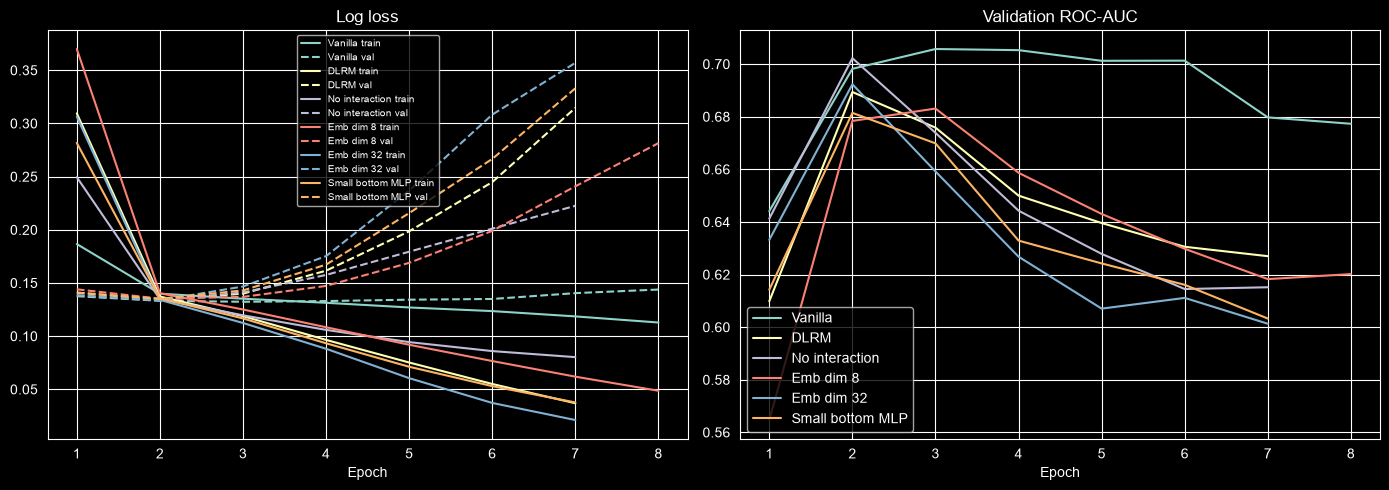

In [11]:
f,ax=plt.subplots(1,2,figsize=(14,5))
for i,(k,(m,h,be,sec)) in enumerate(R.items()):
    e=range(1,len(h["train"])+1)
    ax[0].plot(e,h["train"],color=f"C{i}",label=k+" train")
    ax[0].plot(e,h["val"],"--",color=f"C{i}",label=k+" val")
    ax[1].plot(e,h["auc"],color=f"C{i}",label=k)
ax[0].set(title="Log loss",xlabel="Epoch")
ax[1].set(title="Validation ROC-AUC",xlabel="Epoch")
ax[0].legend(fontsize=7)
ax[1].legend()
plt.tight_layout()
plt.show()

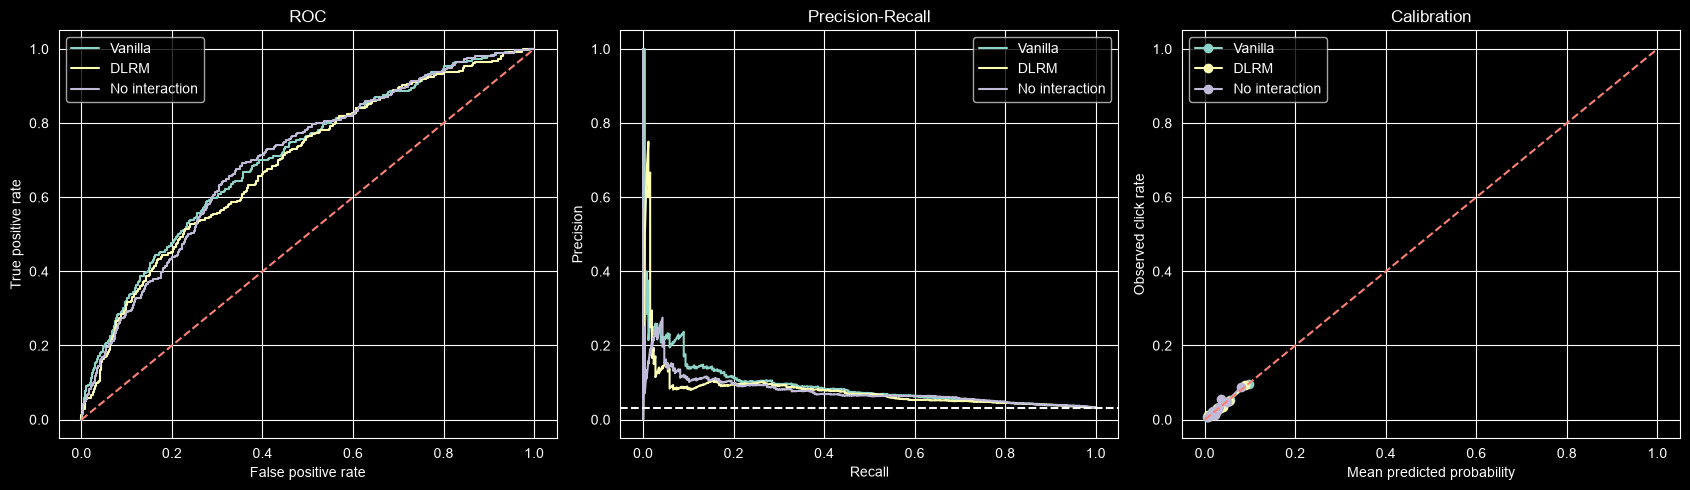

In [12]:
f,ax=plt.subplots(1,3,figsize=(17,5))
for k in ["Vanilla","DLRM","No interaction"]:
    p=VP[k]
    fp,tp,_=roc_curve(yv,p)
    pr,rc,_=precision_recall_curve(yv,p)
    fr,mp=calibration_curve(yv,p,n_bins=10,strategy="quantile")
    ax[0].plot(fp,tp,label=k)
    ax[1].plot(rc,pr,label=k)
    ax[2].plot(mp,fr,"o-",label=k)
ax[0].plot([0,1],[0,1],"--")
ax[1].axhline(yv.mean(),linestyle="--")
ax[2].plot([0,1],[0,1],"--")
ax[0].set(title="ROC",xlabel="False positive rate",ylabel="True positive rate")
ax[1].set(title="Precision-Recall",xlabel="Recall",ylabel="Precision")
ax[2].set(title="Calibration",xlabel="Mean predicted probability",ylabel="Observed click rate")
for a in ax:a.legend()
plt.tight_layout()
plt.show()

In [13]:
el=mk(enc_n(tdf),enc_c(tdf))
if "label" in tdf:
    ye=tdf["label"].astype(int).to_numpy()
    print(pd.DataFrame({k:ev(ye,pred(R[k][0],el),res.loc[k,"Thr"]) for k in R}).T.round(4).to_string())
else:
    pd.DataFrame({"click_probability":pred(R["DLRM"][0],el)}).to_csv("dlrm_test_predictions.csv",index=False)

                  ROC-AUC  PR-AUC  LogLoss     Acc      F1    Prec     Rec
Vanilla            0.6891  0.0684   0.1400  0.8968  0.1224  0.0856  0.2149
DLRM               0.6728  0.0686   0.1406  0.9032  0.1232  0.0884  0.2030
No interaction     0.6769  0.0701   0.1404  0.8959  0.1125  0.0788  0.1970
Emb dim 8          0.6408  0.0597   0.1469  0.9296  0.0997  0.0872  0.1164
Emb dim 32         0.6523  0.0641   0.1423  0.8947  0.1159  0.0806  0.2060
Small bottom MLP   0.6525  0.0665   0.1430  0.9042  0.1243  0.0896  0.2030
